# Demo 2: Transfer Learning for Image Classification

A pretrained ResNet-18 classifies images with a frozen backbone and a
replaced classification head — the standard pipeline for medical imaging.

**Dataset**: CIFAR-10 filtered to 2 classes (airplane vs automobile) for
quick iteration. The workflow is identical for medical data — just swap
in an `ImageFolder` pointing at your chest X-ray directory.

## Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets, models
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: mps


## 1. Prepare the Data

We'll use CIFAR-10 with just 2 classes for quick iteration.
To use your own images, swap `Subset(CIFAR10(...))` with
`ImageFolder("data/your_dataset/")` — everything else stays the same.

In [ ]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [ ]:
# Option A: Use CIFAR-10 subset (2 classes, quick download)
full_train = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transform
)
full_test = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=eval_transform
)


# Filter to just 2 classes (airplane=0, automobile=1) for binary classification
def filter_classes(dataset, classes=(0, 1)):
    # Use .targets to avoid loading/transforming every image
    indices = [i for i, label in enumerate(dataset.targets) if label in classes]
    return torch.utils.data.Subset(dataset, indices)


train_data = filter_classes(full_train)
test_data = filter_classes(full_test)

# Option B: Use ImageFolder for real medical data
# train_data = datasets.ImageFolder("data/montgomery/train", transform=train_transform)
# test_data = datasets.ImageFolder("data/montgomery/test", transform=eval_transform)

print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")

Training samples: 10000
Test samples:     2000


In [ ]:
# Split training into train + val
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_set, val_set = random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_data)}")

Train: 8000, Val: 2000, Test: 2000


## 2. Load Pretrained ResNet-18

We load a ResNet-18 pretrained on ImageNet, freeze the backbone, and
replace the final classification layer.

In [ ]:
# Load pretrained model
model = models.resnet18(weights="DEFAULT")

# Look at the original classification head
print(f"Original fc layer: {model.fc}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Original fc layer: Linear(in_features=512, out_features=1000, bias=True)
Total parameters: 11,689,512


In [ ]:
# Freeze all backbone parameters
for param in model.parameters():
    param.requires_grad = False

# Replace the classification head for binary classification
model.fc = nn.Sequential(
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2),
)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(
    f"Trainable parameters: {trainable:,} / {total:,} ({100 * trainable / total:.1f}%)"
)

model = model.to(device)

Trainable parameters: 65,922 / 11,242,434 (0.6%)


## 3. What the Frozen Backbone Sees

The frozen layers extract features learned on ImageNet — edges, textures,
shapes — that transfer to new tasks. Here are the first 16 feature maps
from `layer1` for a single input image.

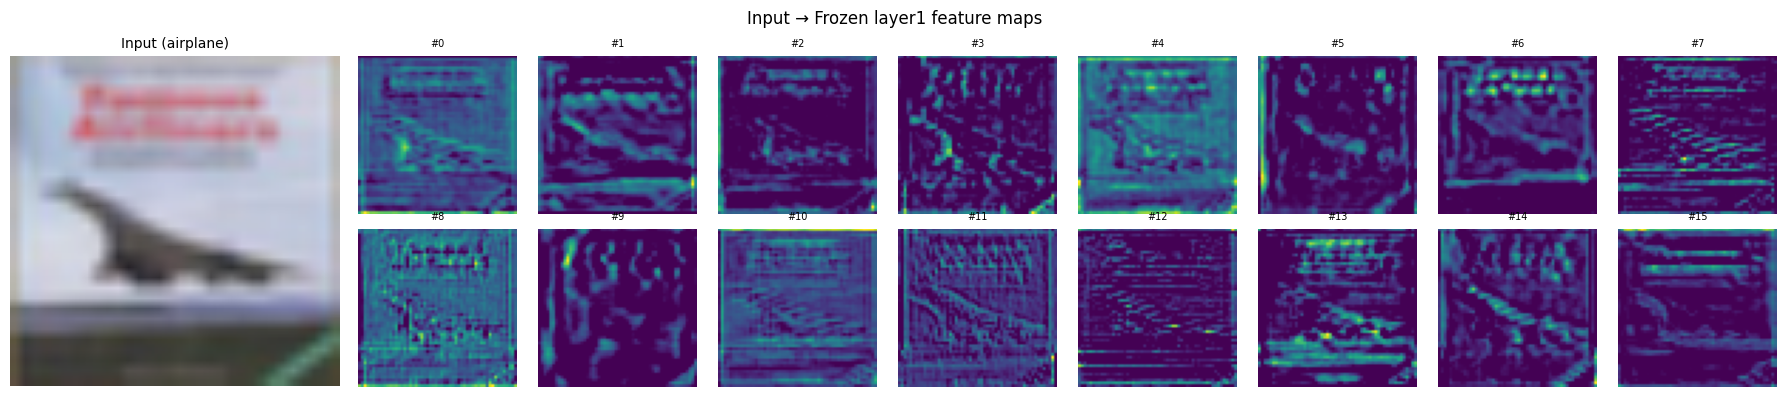

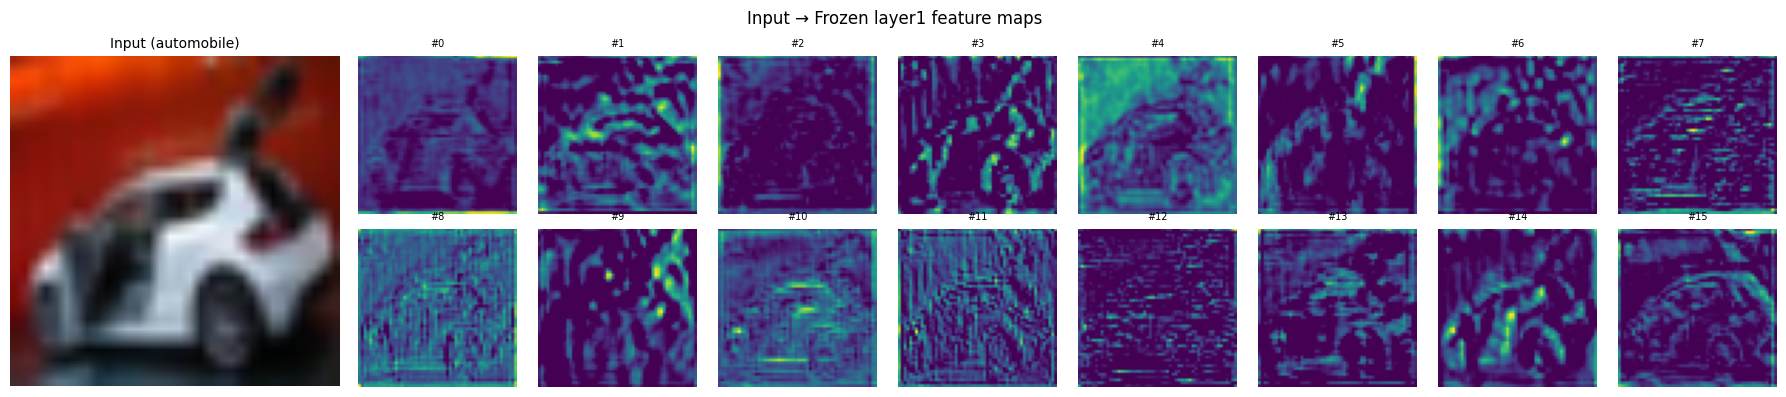

In [ ]:
class_names = ["airplane", "automobile"]

# Hook into an intermediate layer to capture feature maps
activations = {}


def hook_fn(module, input, output):
    activations["layer1"] = output


handle = model.layer1.register_forward_hook(hook_fn)

# Inverse normalization for display
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

# Run two sample images through the frozen backbone
sample_batch, sample_labels = next(iter(test_loader))
num_samples = 2
feature_maps = []

for i in range(num_samples):
    with torch.no_grad():
        _ = model(sample_batch[i : i + 1].to(device))
    feature_maps.append(activations["layer1"][0].cpu())

handle.remove()

# Show each input image alongside its feature maps
for idx in range(num_samples):
    fig, axes = plt.subplots(
        2, 9, figsize=(18, 4), gridspec_kw={"width_ratios": [2] + [1] * 8}
    )
    # Input image spans both rows
    ax_img = fig.add_subplot(2, 9, (1, 10))
    img_display = inv_normalize(sample_batch[idx]).clamp(0, 1)
    ax_img.imshow(img_display.permute(1, 2, 0).numpy())
    ax_img.set_title(f"Input ({class_names[sample_labels[idx]]})", fontsize=10)
    ax_img.axis("off")
    # Hide the original grid cells behind the merged subplot
    axes[0, 0].axis("off")
    axes[1, 0].axis("off")

    # Feature maps in remaining columns
    feat = feature_maps[idx]
    for i in range(16):
        row, col = divmod(i, 8)
        axes[row, col + 1].imshow(feat[i], cmap="viridis")
        axes[row, col + 1].set_title(f"#{i}", fontsize=7)
        axes[row, col + 1].axis("off")

    fig.suptitle("Input → Frozen layer1 feature maps", fontsize=12)
    fig.tight_layout()
    plt.show()

## 4. Train the Model

Only the classification head is learning — the backbone features stay fixed.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

num_epochs = 5
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    history["train_loss"].append(avg_train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100.0 * correct / total
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{num_epochs} — "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}, "
        f"Val Acc: {val_acc:.1f}%"
    )

Epoch 1/5 — Train Loss: 0.2543, Val Loss: 0.1474, Val Acc: 94.8%
Epoch 2/5 — Train Loss: 0.1673, Val Loss: 0.1433, Val Acc: 94.8%
Epoch 3/5 — Train Loss: 0.1722, Val Loss: 0.1645, Val Acc: 93.3%
Epoch 4/5 — Train Loss: 0.1790, Val Loss: 0.2175, Val Acc: 91.2%
Epoch 5/5 — Train Loss: 0.1576, Val Loss: 0.1326, Val Acc: 94.5%


## 5. Plot Training Curves

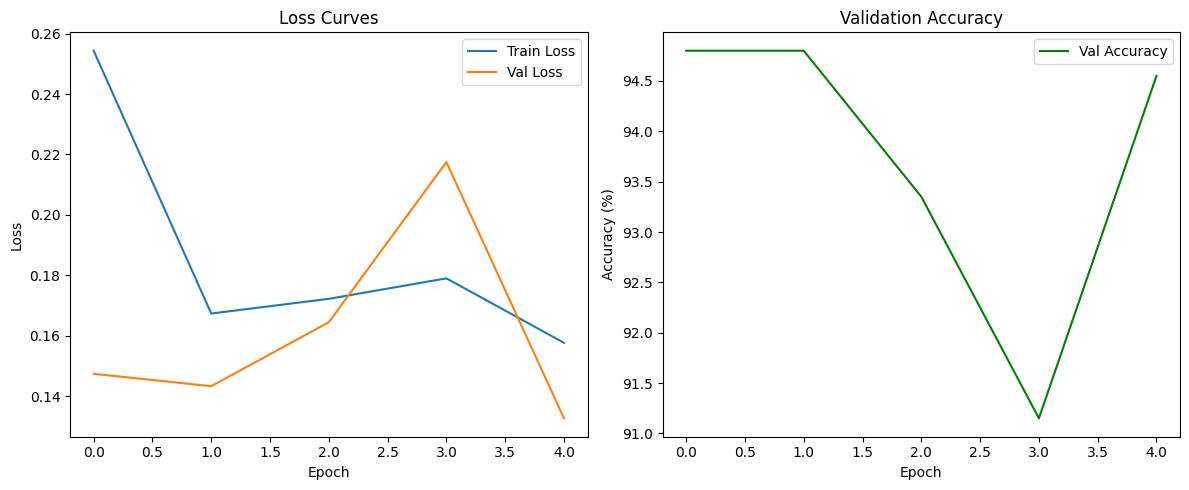

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss Curves")
ax1.legend()

ax2.plot(history["val_acc"], label="Val Accuracy", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Validation Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Evaluate on Test Set

              precision    recall  f1-score   support

    airplane       0.99      0.90      0.94      1000
  automobile       0.91      0.99      0.95      1000

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



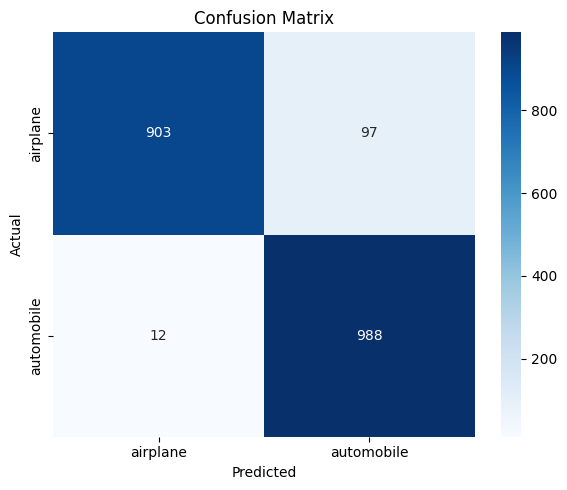

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. Visualize Predictions

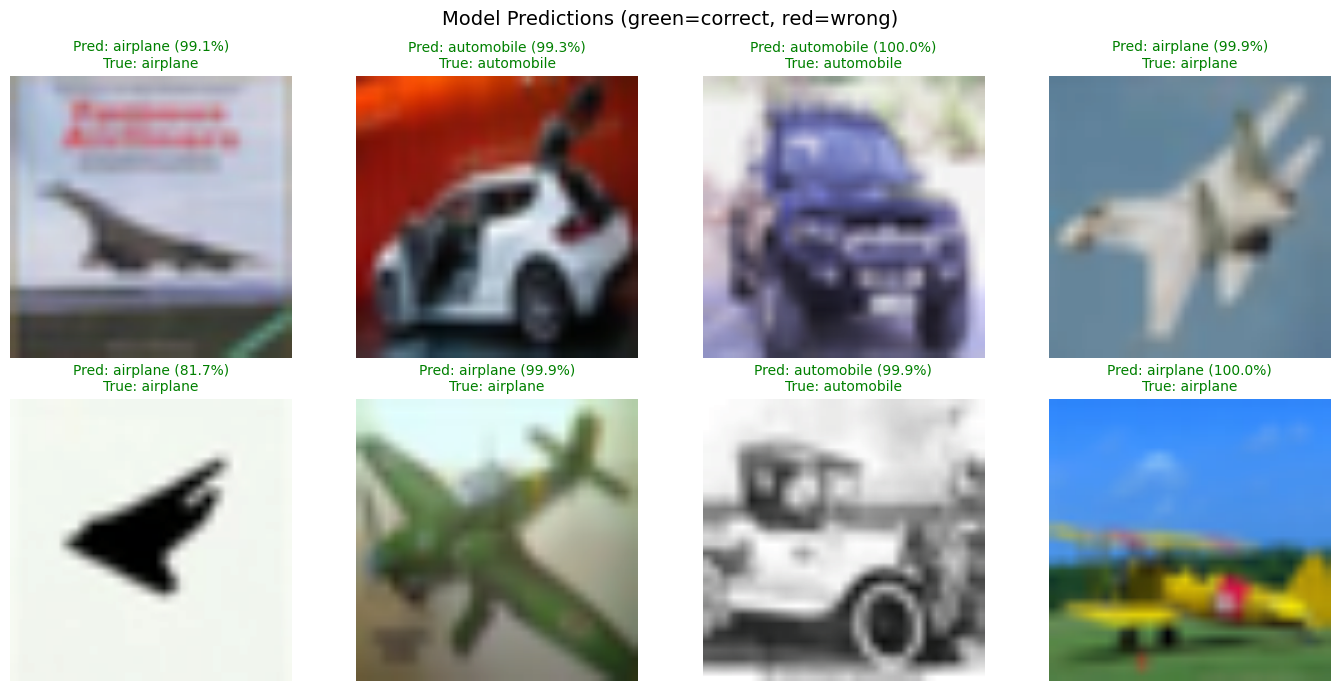

In [ ]:
from torchvision.transforms.functional import to_pil_image

# Inverse normalization as a standard transform (negated mean/std)
inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

# Get a batch of test images
images, labels = next(iter(test_loader))
images_device = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images_device)
    probs = torch.softmax(outputs, dim=1)
    _, preds = outputs.max(1)

# Display predictions
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = inv_normalize(images[i])
    ax.imshow(to_pil_image(img))
    color = "green" if preds[i] == labels[i] else "red"
    ax.set_title(
        f"Pred: {class_names[preds[i]]} ({probs[i][preds[i]]:.1%})\n"
        f"True: {class_names[labels[i]]}",
        color=color,
        fontsize=10,
    )
    ax.axis("off")
plt.suptitle("Model Predictions (green=correct, red=wrong)", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Save the Model

In [ ]:
torch.save(model.state_dict(), "resnet18_classifier.pt")
print("Model saved to resnet18_classifier.pt")

# To load later:
# model.load_state_dict(torch.load("resnet18_classifier.pt"))

Model saved to resnet18_classifier.pt
